In [97]:
import pandas as pd

In [98]:
df = pd.read_csv(r"dataset\BBC News Temporal.csv")
print(f'''
      Shape: {df.shape}
      Columns: {df.columns.tolist()}
      Category column values: {df['Category'].unique().tolist()}
''')


      Shape: (1490, 4)
      Columns: ['ArticleId', 'Text', 'Category', 'pubDate']
      Category column values: ['business', 'tech', 'politics', 'sport', 'entertainment']



## Data filtering

In [99]:
tech_data = df[df.Category=='tech']
print(tech_data.shape)
tech_data.head()

(261, 4)


,ArticleId,Text,Category,pubDate
3,1976,lifestyle governs mobile choice faster bett...,tech,"Mon, 07 Mar 2022 00:05:40 GMT"
19,1552,moving mobile improves golf swing a mobile pho...,tech,"Fri, 04 Mar 2022 22:09:49 GMT"
24,405,bt boosts its broadband packages british telec...,tech,"Fri, 04 Mar 2022 18:32:49 GMT"
26,702,peer-to-peer nets here to stay peer-to-peer ...,tech,"Fri, 04 Mar 2022 12:54:25 GMT"
30,1951,pompeii gets digital make-over the old-fashion...,tech,"Sun, 06 Mar 2022 09:14:03 GMT"


In [100]:
import nltk
# nltk.download('punkt')
from nltk.tokenize import sent_tokenize

In [101]:
tech_data = tech_data.copy()

tech_data["num_sent"] = tech_data["Text"].apply(lambda x: len(sent_tokenize(x)))
filtered_data = tech_data[tech_data['Text'].str.contains('microsoft',case=False,na=False)]

filtered_data = filtered_data.copy()
filtered_data = filtered_data[(filtered_data["num_sent"] <= 15)]
filtered_data = filtered_data.drop_duplicates(subset=['Text'], keep='first')

filtered_data.to_csv(r'filtered_data.csv',index=False)

In [102]:
print(filtered_data.shape)
filtered_data.sort_values('num_sent')

(9, 5)


,ArticleId,Text,Category,pubDate,num_sent
301,428,microsoft takes on desktop search microsoft ha...,tech,"Fri, 11 Mar 2022 22:16:48 GMT",10
651,1615,microsoft seeking spyware trojan microsoft is ...,tech,"Sun, 20 Mar 2022 02:51:19 GMT",10
428,69,microsoft gets the blogging bug software giant...,tech,"Mon, 14 Mar 2022 17:55:20 GMT",13
509,2042,virus poses as christmas e-mail security firms...,tech,"Thu, 17 Mar 2022 01:08:07 GMT",13
861,184,xbox power cable fire fear microsoft has sai...,tech,"Fri, 25 Mar 2022 10:33:43 GMT",13
1179,728,anti-spam laws bite spammer hard the net s sel...,tech,"Fri, 01 Apr 2022 20:58:12 GMT",13
48,277,halo 2 sells five million copies microsoft is ...,tech,"Sun, 06 Mar 2022 21:55:52 GMT",14
589,1604,joke e-mail virus tricks users a virus that di...,tech,"Fri, 18 Mar 2022 00:18:09 GMT",15
1305,1004,microsoft releases bumper patches microsoft ha...,tech,"Mon, 04 Apr 2022 01:51:59 GMT",15


## Sentence Spliting

In [103]:
sentences = []
source_ids = []
pub_date = []

for idx, row in filtered_data.iterrows():
    article_id = row["ArticleId"]
    publish_date = row["pubDate"]
    text = row["Text"]
    
    sents = sent_tokenize(text)
    
    for s in sents:
        s = s.strip()
        if len(s) > 0:
            sentences.append(s)
            source_ids.append(article_id)
            pub_date.append(publish_date)

In [104]:
sent_df = pd.DataFrame({
    "article_id": source_ids,
    "sentence": sentences,
    "pub_date": pub_date
})

In [105]:
print(sent_df.shape)
sent_df.head(20)

(116, 3)


,article_id,sentence,pub_date
0,277,halo 2 sells five million copies microsoft is ...,"Sun, 06 Mar 2022 21:55:52 GMT"
1,277,halo 2 has proved popular online with gamers ...,"Sun, 06 Mar 2022 21:55:52 GMT"
2,277,according to microsoft nine out of 10 xbox li...,"Sun, 06 Mar 2022 21:55:52 GMT"
3,277,the sequel to the best-selling need for speed:...,"Sun, 06 Mar 2022 21:55:52 GMT"
4,277,the racing game moved up one spot to first pla...,"Sun, 06 Mar 2022 21:55:52 GMT"
5,277,halo 2 dropped one place to five while half-l...,"Sun, 06 Mar 2022 21:55:52 GMT"
6,277,last week s new releases goldeneye: rogue age...,"Sun, 06 Mar 2022 21:55:52 GMT"
7,277,record numbers of warcraft fans are settling i...,"Sun, 06 Mar 2022 21:55:52 GMT"
8,277,on the opening day of the world of warcraft ma...,"Sun, 06 Mar 2022 21:55:52 GMT"
9,277,on the evening of the first day more than 100 ...,"Sun, 06 Mar 2022 21:55:52 GMT"


## Sentence preprocessing

In [106]:
import re
import unicodedata

In [107]:
clean_sentences = []
kept_source_ids = []
kept_pub_date = []

for idx, row in sent_df.iterrows():
    s = row['sentence']
    
    if not isinstance(s, str):
        continue
    
    s = s.strip()
    
    if len(s.split()) < 5:
        continue
    
    if not re.search(r"[A-Za-z]", s):
        continue
    
    if len(re.sub(r"[A-Za-z0-9]", "", s)) / max(1, len(s)) > 0.5:
        continue
    
    bad_patterns = [
        r"click here", r"share this", r"subscribe", r"read more",
        r"copyright", r"all rights reserved"
    ]
    if any(re.search(pat, s.lower()) for pat in bad_patterns):
        continue
    
    clean_sentences.append(s)
    kept_source_ids.append(row['article_id'])
    kept_pub_date.append(row["pub_date"])

In [108]:
assert len(clean_sentences) == len(kept_source_ids)
assert len(clean_sentences) == len(kept_pub_date)

In [109]:
filtered_sent_df = pd.DataFrame({
    "article_id": kept_source_ids,
    "sentence": clean_sentences,
    "pub_date": kept_pub_date,
    })

print("Before:", sent_df.shape)
print("After:", filtered_sent_df.shape)

Before: (116, 3)
After: (116, 3)


In [110]:
filtered_sent_df.head()

,article_id,sentence,pub_date
0,277,halo 2 sells five million copies microsoft is ...,"Sun, 06 Mar 2022 21:55:52 GMT"
1,277,halo 2 has proved popular online with gamers ...,"Sun, 06 Mar 2022 21:55:52 GMT"
2,277,according to microsoft nine out of 10 xbox li...,"Sun, 06 Mar 2022 21:55:52 GMT"
3,277,the sequel to the best-selling need for speed:...,"Sun, 06 Mar 2022 21:55:52 GMT"
4,277,the racing game moved up one spot to first pla...,"Sun, 06 Mar 2022 21:55:52 GMT"


In [111]:
def light_clean(text):
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[-_]{2,}', ' ', text)
    text = re.sub(r'([!?.,]){2,}', r'\1', text)
    text = ''.join(ch for ch in text if unicodedata.category(ch)[0] != "C")
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    
    return text

In [112]:
df_sent = filtered_sent_df.copy()

df_sent["clean_sentence"] = df_sent["sentence"].astype(str).apply(light_clean)

In [113]:
before = df_sent.shape[0]
df_sent = df_sent[df_sent["clean_sentence"].str.strip() != ""].reset_index(drop=True)
after = df_sent.shape[0]

final_df = df_sent[["article_id", "clean_sentence","pub_date"]].rename(columns={"clean_sentence": "sentence"})

In [114]:
print(f"Sentences before cleaning: {before}")
print(f"Sentences after cleaning & removing empties: {after}")

Sentences before cleaning: 116
Sentences after cleaning & removing empties: 116


In [115]:
final_df.head()

,article_id,sentence,pub_date
0,277,halo 2 sells five million copies microsoft is ...,"Sun, 06 Mar 2022 21:55:52 GMT"
1,277,halo 2 has proved popular online with gamers n...,"Sun, 06 Mar 2022 21:55:52 GMT"
2,277,according to microsoft nine out of 10 xbox liv...,"Sun, 06 Mar 2022 21:55:52 GMT"
3,277,the sequel to the best-selling need for speed:...,"Sun, 06 Mar 2022 21:55:52 GMT"
4,277,the racing game moved up one spot to first pla...,"Sun, 06 Mar 2022 21:55:52 GMT"


## Sentence Embedings

In [116]:
from sentence_transformers import SentenceTransformer
import numpy as np

In [117]:
MODEL_NAME = "all-MiniLM-L6-v2"
BATCH_SIZE = 64 

model = SentenceTransformer(MODEL_NAME)

In [118]:
sentences = final_df["sentence"].astype(str).tolist()
print("Number of sentences to encode:", len(sentences))

Number of sentences to encode: 116


In [119]:
embeddings = model.encode(sentences,
                batch_size=BATCH_SIZE,
                show_progress_bar=True,
                convert_to_numpy=True
            )

print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embeddings shape: (116, 384)


In [120]:
sent_emb_df = final_df.reset_index(drop=True).copy()
sent_emb_df["emb_index"] = np.arange(len(sent_emb_df))

sent_emb_df.head()

,article_id,sentence,pub_date,emb_index
0,277,halo 2 sells five million copies microsoft is ...,"Sun, 06 Mar 2022 21:55:52 GMT",0
1,277,halo 2 has proved popular online with gamers n...,"Sun, 06 Mar 2022 21:55:52 GMT",1
2,277,according to microsoft nine out of 10 xbox liv...,"Sun, 06 Mar 2022 21:55:52 GMT",2
3,277,the sequel to the best-selling need for speed:...,"Sun, 06 Mar 2022 21:55:52 GMT",3
4,277,the racing game moved up one spot to first pla...,"Sun, 06 Mar 2022 21:55:52 GMT",4


## Dimensionality reduction

In [121]:
import umap

In [122]:
print("Original embedding shape:", embeddings.shape)

Original embedding shape: (116, 384)


In [123]:
n_components_cluster = 20
n_neighbors = 15

In [124]:
umap_cluster = umap.UMAP(
    n_components=n_components_cluster,
    n_neighbors=n_neighbors,
    metric='cosine',
    random_state=42
)

emb_reduced = umap_cluster.fit_transform(embeddings)
print("Reduced embedding shape:", emb_reduced.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embedding shape: (116, 20)


In [125]:
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    metric='cosine',
    random_state=42
)

emb_2d = umap_2d.fit_transform(embeddings)
print("2D embedding shape:", emb_2d.shape)

2D embedding shape: (116, 2)


c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [126]:
sent_emb_df["umap_x"] = emb_2d[:, 0]
sent_emb_df["umap_y"] = emb_2d[:, 1]

sent_emb_df.head()

,article_id,sentence,pub_date,emb_index,umap_x,umap_y
0,277,halo 2 sells five million copies microsoft is ...,"Sun, 06 Mar 2022 21:55:52 GMT",0,2.027306,14.828272
1,277,halo 2 has proved popular online with gamers n...,"Sun, 06 Mar 2022 21:55:52 GMT",1,1.911170,14.823671
2,277,according to microsoft nine out of 10 xbox liv...,"Sun, 06 Mar 2022 21:55:52 GMT",2,2.268620,14.766386
3,277,the sequel to the best-selling need for speed:...,"Sun, 06 Mar 2022 21:55:52 GMT",3,1.485189,14.701770
4,277,the racing game moved up one spot to first pla...,"Sun, 06 Mar 2022 21:55:52 GMT",4,1.582816,14.903230


## HDBSCAN Clustering

In [127]:
import hdbscan

In [128]:
MIN_CLUSTER_SIZE = 4    # minimum number of sentences to form a cluster (smaller -> more clusters)
MIN_SAMPLES = None
METRIC = "euclidean"

In [129]:

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric=METRIC,
    cluster_selection_method="eom",
    prediction_data=True,
    core_dist_n_jobs=4
)

In [130]:
labels = clusterer.fit_predict(emb_reduced)
probs = clusterer.probabilities_

sent_emb_df = sent_emb_df.copy().reset_index(drop=True)
sent_emb_df["hdb_cluster"] = labels
sent_emb_df["hdb_prob"] = probs

n_sentences = sent_emb_df.shape[0]
n_noise = int((sent_emb_df["hdb_cluster"] == -1).sum())
clusters_found = sorted([c for c in set(labels) if c != -1])
n_clusters = len(clusters_found)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [131]:
print(f"Total sentences clustered: {n_sentences}")
print(f"Noise sentences (label -1): {n_noise}")
print(f"Clusters found (excluding noise): {n_clusters}")
print("Cluster ids:", clusters_found)

print("\nCluster sizes (including noise -1):")
print(sent_emb_df["hdb_cluster"].value_counts().sort_index())

Total sentences clustered: 116
Noise sentences (label -1): 10
Clusters found (excluding noise): 5
Cluster ids: [0, 1, 2, 3, 4]

Cluster sizes (including noise -1):
-1    10
 0    54
 1    12
 2    22
 3    11
 4     7
Name: hdb_cluster, dtype: int64


In [132]:

# Optional: show top sentences per cluster by probability (quick sanity check)
print("\nTop representative sentences per cluster (highest membership probability):")
for c in clusters_found:
    subset = sent_emb_df[sent_emb_df["hdb_cluster"] == c].sort_values("hdb_prob", ascending=False).head(3)
    print(f"\nCluster {c} (n={len(subset)}):")
    for _, row in subset.iterrows():
        print(" -", row["sentence"][:200], " ... (prob:{:.2f})".format(row["hdb_prob"]))


Top representative sentences per cluster (highest membership probability):

Cluster 0 (n=3):
 - microsoft s program can be used as a toolbar on the windows desktop the internet explorer browser and within the outlook e-mail program.  ... (prob:1.00)
 - security firm network box said that it stopped more than 30 000 copies an hour of the virus as the outbreak reached a peak.  ... (prob:1.00)
 - anti-virus firms urged users to be wary of unexpected e-mail messages bearing attachments and to update their software to ensure they are protected against the latest threats.  ... (prob:1.00)

Cluster 1 (n=3):
 - scott richter the man behind optinrealbig.com and billions of junk mail messages said lawsuits had forced the company into chapter 11. optinrealbig was fighting several legal battles most notably agai  ... (prob:1.00)
 - microsoft is seeking millions in dollars in damages from optinrealbig under anti-spam laws that impose penalties for every violation.  ... (prob:1.00)
 - in a statemen

In [133]:
sent_emb_df.to_csv(r"dataset\output\sentences_with_hdbscan_clusters.csv", index=False)

## Keywords for each cluster

In [134]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [135]:
TOP_N_KEYWORDS = 10
TOP_N_REP_SENTENCES = 5
CONFIDENCE_THRESHOLD = 0.60

In [136]:
df = sent_emb_df.copy().reset_index(drop=True)

vectorizer = TfidfVectorizer(stop_words="english", max_features=8000, ngram_range=(1,2))
X_tfidf = vectorizer.fit_transform(df["sentence"].astype(str))
terms = np.array(vectorizer.get_feature_names_out())

clusters = sorted([c for c in df["hdb_cluster"].unique() if c != -1])

In [137]:
cluster_summaries = []

print("Found clusters (excluding noise):", clusters)
for c in clusters:
    high_conf_idx = df[(df["hdb_cluster"] == c) & (df["hdb_prob"] >= CONFIDENCE_THRESHOLD)].index.to_numpy()
    if high_conf_idx.size == 0:
        idxs = df[df["hdb_cluster"] == c].index.to_numpy()
    else:
        idxs = high_conf_idx

    cluster_tfidf_sum = X_tfidf[idxs].sum(axis=0).A1
    top_term_indices = cluster_tfidf_sum.argsort()[::-1][:TOP_N_KEYWORDS]
    top_keywords = terms[top_term_indices].tolist()

    cluster_emb_idxs = df[df["hdb_cluster"] == c].index.to_numpy()
    cluster_embs = emb_reduced[cluster_emb_idxs]
    if cluster_embs.shape[0] == 0:
        rep_sentences = []
    else:
        centroid = cluster_embs.mean(axis=0, keepdims=True)
        sims = cosine_similarity(cluster_embs, centroid).reshape(-1)
        top_local = sims.argsort()[::-1][:TOP_N_REP_SENTENCES]
        top_global_idxs = cluster_emb_idxs[top_local]
        rep_sentences = df.loc[top_global_idxs, ["sentence", "hdb_prob", "article_id"]].to_dict(orient="records")

    summary = {
        "cluster_id": c,
        "n_sentences": int((df["hdb_cluster"] == c).sum()),
        "top_keywords": top_keywords,
        "representative_sentences": rep_sentences
    }
    cluster_summaries.append(summary)

    print("\n=== Cluster", c, f"(n={summary['n_sentences']}) ===")
    print("Top keywords:", ", ".join(top_keywords[:10]))
    print("Representative sentences:")
    for rep in rep_sentences:
        prob = rep.get("hdb_prob", None)
        aid = rep.get("article_id", None)
        sent_preview = rep["sentence"]
        print(f" - (prob={prob:.2f}, article_id={aid}) {sent_preview}")

Found clusters (excluding noise): [0, 1, 2, 3, 4]

=== Cluster 0 (n=54) ===
Top keywords: virus, mail, microsoft, software, security, critical, anti, users, program, anti virus
Representative sentences:
 - (prob=0.91, article_id=2042) on infected machines the virus tries to disable anti-virus and firewall software and opens up a backdoor on the pc to hand over control to the writer of the virus.
 - (prob=0.87, article_id=1604) the virus can strike computers running windows 95 98 me nt 2000 and xp.
 - (prob=1.00, article_id=1615) it may also try to steal online banking passwords or other personal information by tracking users keystrokes.
 - (prob=1.00, article_id=1615) stephen toulouse a security manager at microsoft said the malicious program was called bankash-a trojan and was being sent as an e-mail attachment.
 - (prob=1.00, article_id=1604) as well as plundering microsoft outlook for e-mail addresses to send itself to bagle.at also tries to turn off the firewall and security centre

In [138]:
summary_rows = []
for s in cluster_summaries:
    summary_rows.append({
        "cluster_id": s["cluster_id"],
        "n_sentences": s["n_sentences"],
        "top_keywords": "; ".join(s["top_keywords"]),
        "representative_sentences": " || ".join([f"(p={r['hdb_prob']:.2f},aid={r['article_id']}) {r['sentence']}" for r in s["representative_sentences"]])
    })


In [139]:
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(r"dataset\output\cluster_summaries.csv", index=False)

## Cluster visualization

In [140]:
import matplotlib.pyplot as plt

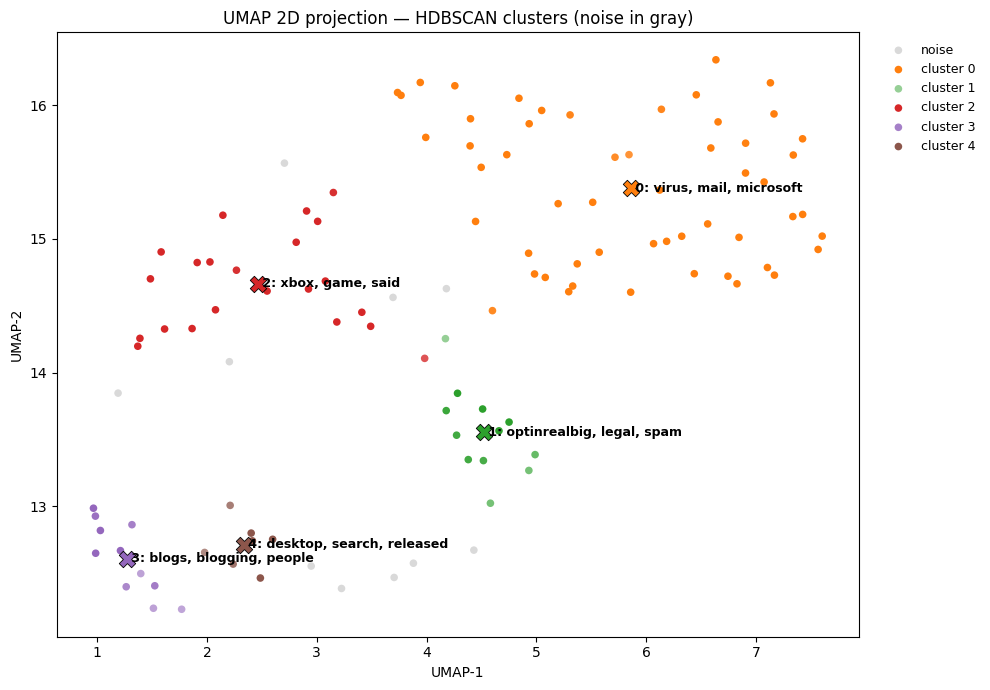

In [141]:
plt.rcParams["figure.dpi"] = 120
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 7))

df = sent_emb_df.copy().reset_index(drop=True)
xs = df["umap_x"].values
ys = df["umap_y"].values
labels = df["hdb_cluster"].values
probs = df["hdb_prob"].values

# Determine unique clusters and colors
unique_clusters = sorted(df["hdb_cluster"].unique())
# assign gray for noise (-1)
palette = plt.get_cmap("tab10")
cluster_colors = {c: (0,0,0) if c == -1 else palette(i % 50) for i, c in enumerate(unique_clusters)}

alphas = np.clip((probs - 0.2) / 0.8, 0.15, 1.0)
for c in unique_clusters:
    mask = (labels == c)
    ax.scatter(xs[mask], ys[mask],
               s=30,
               alpha=alphas[mask],
               color=cluster_colors[c],
               label=("noise" if c == -1 else f"cluster {c}"),
               linewidths=0.2,
               edgecolors="none")

non_noise = [c for c in unique_clusters if c != -1]
centroids = {}
for c in non_noise:
    mask = (labels == c)
    if mask.sum() == 0:
        continue
    cx = xs[mask].mean()
    cy = ys[mask].mean()
    centroids[c] = (cx, cy)
    ax.scatter(cx, cy, s=140, marker="X", color=cluster_colors[c], edgecolor="k", linewidth=0.6)

if 'summary_df' in globals():
    for _, row in summary_df.iterrows():
        cid = row['cluster_id']
        if cid in centroids:
            cx, cy = centroids[cid]
            kw = row['top_keywords'].split(';')[:3] if isinstance(row['top_keywords'], str) else []
            ax.text(cx, cy, f" {cid}: " + ", ".join([k.strip() for k in kw]),
                    fontsize=9, fontweight='bold', verticalalignment='center')

ax.set_title("UMAP 2D projection — HDBSCAN clusters (noise in gray)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
